# Data Cleaning

In [11]:
import os
import cv2
import random
import matplotlib.pyplot as plt 

## Set Dataset Path

In [12]:
import os

input_folder = "PCB_DATASET/images"
output_folder = "Clean_Dataset"

os.makedirs(output_folder, exist_ok=True)

print("Input:", input_folder)
print("Output:", output_folder)

Input: PCB_DATASET/images
Output: Clean_Dataset


## Load Dataset

In [13]:
classes = [
    folder for folder in os.listdir(input_folder)
    if os.path.isdir(os.path.join(input_folder, folder))
]

print(classes)

['Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper']


In [14]:
total_images = 0

for cls in classes:
    class_path = os.path.join(input_folder, cls)

    files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    total_images += len(files)

print("Classes:", classes)
print("Total Images:", total_images)

Classes: ['Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper']
Total Images: 693


## Check Image - Remove Corrupted Images

In [15]:
valid_images = []
corrupted_images = []

for cls in classes:

    class_path = os.path.join(input_folder, cls)

    files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for file in files:

        path = os.path.join(class_path, file)

        img = cv2.imread(path)

        if img is None:
            corrupted_images.append((cls, file))
        else:
            valid_images.append((cls, file))

print("Valid Images:", len(valid_images))
print("Corrupted Images:", len(corrupted_images))

Valid Images: 693
Corrupted Images: 0


## Display Sample Images

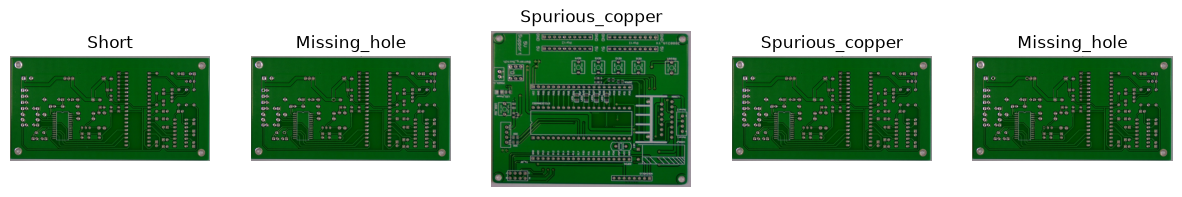

In [16]:
sample_images = random.sample(valid_images, min(5, len(valid_images)))

plt.figure(figsize=(15,5))

for i, (cls, file) in enumerate(sample_images):

    path = os.path.join(input_folder, cls, file)

    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

## Image Cleaning Cell

In [19]:
target_size = (512, 512)

for cls, file in valid_images:

    img_path = os.path.join(input_folder, cls, file)

    img = cv2.imread(img_path)

    if img is None:
        continue

    # Resize only
    img = cv2.resize(img, target_size)

    # Create output folder for each class
    save_folder = os.path.join(output_folder, cls)
    os.makedirs(save_folder, exist_ok=True)

    # Save image
    save_path = os.path.join(save_folder, file)

    cv2.imwrite(save_path, img)

print("Data Cleaning Completed!")

Data Cleaning Completed!


## Display Cleaned Images

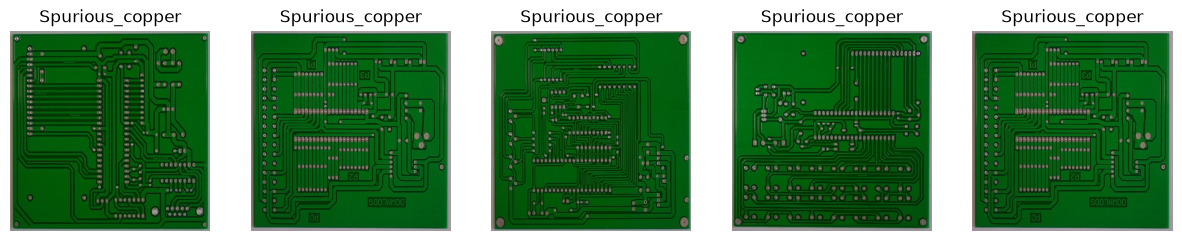

In [20]:
sample_class = random.choice(classes)

clean_folder = os.path.join(output_folder, sample_class)

clean_files = [
    f for f in os.listdir(clean_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

sample = random.sample(clean_files, min(5, len(clean_files)))

plt.figure(figsize=(15,5))

for i, file in enumerate(sample):

    img = cv2.imread(os.path.join(clean_folder, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(sample_class)
    plt.axis("off")

plt.show()

## Dataset Summary

In [21]:
processed_images = 0

for cls in classes:
    folder = os.path.join(output_folder, cls)

    if os.path.exists(folder):
        processed_images += len([
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

print("========== Dataset Summary ==========")
print("Total Images     :", total_images)
print("Valid Images     :", len(valid_images))
print("Corrupted Images :", len(corrupted_images))
print("Processed Images :", processed_images)

========== Dataset Summary ==========
Total Images     : 693
Valid Images     : 693
Corrupted Images : 0
Processed Images : 693
